In [2]:
import numpy as np 

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import tensorflow as tf
import cv2


In [22]:
data_set=pd.read_csv("churn_modelling.csv")

In [23]:
X=data_set.iloc[:,3:13]
Y=data_set.iloc[:,13]

In [24]:
# creating dummy data 
geography=pd.get_dummies(X["Geography"], drop_first=True)
gender=pd.get_dummies(X["Gender"], drop_first=True)

In [25]:
# concatinating the frame
X=pd.concat([X, geography, gender], axis=1)

In [28]:
X=X.drop(["Geography","Gender"],axis=1)

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.2, random_state=0)

In [74]:
# feature scalling
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.fit_transform(X_test)

In [48]:
# part 2: Now let's make ANN
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LeakyReLU, PReLU, ELU
from keras.layers import Dropout

In [50]:
# initalizing the ANN
clasifier=Sequential()

In [57]:
# adding first hidden layer 
clasifier.add(Dense(units=6, kernel_initializer='he_uniform', activation='relu', input_dim=11))

In [59]:
# adding second hidden layer
clasifier.add(Dense(units=6, kernel_initializer='he_uniform', activation='relu'))

In [64]:
#adding the Output layerr
clasifier.add(Dense(units=1, kernel_initializer='glorot_uniform', activation='sigmoid'))


In [65]:
clasifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 6)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │              42 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               7 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

In [66]:
clasifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [69]:
# fitting ANN to train set 
model_history=clasifier.fit(X_train,Y_train, validation_split=0.33, batch_size=10, epochs=100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8000 - loss: 0.4849 - val_accuracy: 0.8031 - val_loss: 0.4564
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8082 - loss: 0.4400 - val_accuracy: 0.8065 - val_loss: 0.4426
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8100 - loss: 0.4303 - val_accuracy: 0.8073 - val_loss: 0.4364
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8143 - loss: 0.4243 - val_accuracy: 0.8126 - val_loss: 0.4317
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8162 - loss: 0.4195 - val_accuracy: 0.8129 - val_loss: 0.4283
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8196 - loss: 0.4158 - val_accuracy: 0.8122 - val_loss: 0.4271
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8218 - loss: 0.4126 - val_accuracy: 0.8179 - val_loss: 0.4242
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8244 - loss: 0.4097 - val_accu

<function matplotlib.pyplot.show(close=None, block=None)>

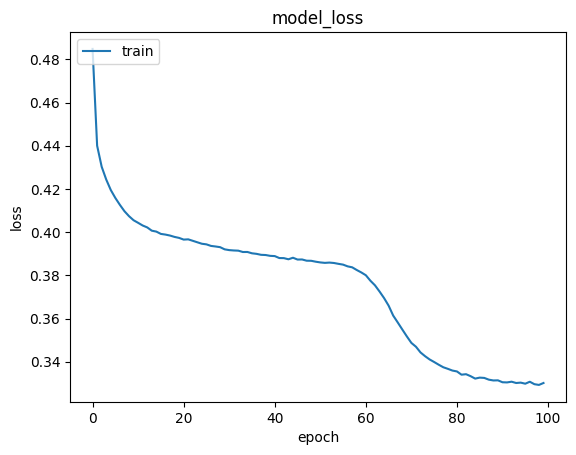

In [86]:
plt.plot(model_history.history['loss'])
plt.title('model_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','test'], loc='upper left')
plt.show

In [87]:
# predicting test set result
Y_pred=clasifier.predict(X_test)
Y_pred=(Y_pred>0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step


In [88]:
# making confusion matrix

from sklearn.metrics import confusion_matrix
cm=confusion_matrix(Y_test,Y_pred)


In [89]:
cm

array([[1514,   81],
       [ 196,  209]])

In [92]:
from sklearn.metrics import accuracy_score
score=accuracy_score(Y_pred, Y_test)

In [93]:
score

0.8615